# Temporal Analysis: LSH-Based Duplicate Detection
## Health & Personal Care Category with Stratified Sampling

In [2]:
import sys
print(sys.version)
print(spark.version)

3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:38:13) [GCC 12.3.0]
3.5.1


In [3]:
from pyspark.sql.functions import (
    col, from_unixtime, to_date, year, when, count, rand,
    monotonically_increasing_id, trim, length, udf, size as array_size
)
from pyspark.sql.types import BooleanType
from pyspark.ml.feature import MinHashLSH, RegexTokenizer, HashingTF
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

## 1. Load Data

In [4]:
# Load data (assuming df_clean is already loaded from your GCS path)
gcs_path = "gs://msca-bdp-students-bucket/notebooks/jiayue1/reviews_meta_final_parquet/"
df_clean = spark.read.parquet(gcs_path)

print("Data loaded!")
df_clean.printSchema()

Data loaded!
root
 |-- parent_asin: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- product_title: string (nullable = true)
 |-- store: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- product_avg_rating: double (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: string (nullable = true)



## 2. Helper Functions for LSH Analysis

In [5]:
def prepare_lsh_model(df, text_col, num_hash_tables=5, min_valid_rows=10):
    """
    Prepare LSH model for similarity detection with robust empty vector handling.
    
    Args:
        df: Input DataFrame
        text_col: Column name containing text
        num_hash_tables: Number of hash tables for LSH
        min_valid_rows: Minimum number of valid rows required
    
    Returns:
        Tuple of (lsh_model, df_hashed) or (None, None) if insufficient data
    """
    print(f"  Processing column: {text_col}")
    
    # Filter non-null, non-empty values with minimum length
    df_filtered = df.filter(
        (col(text_col).isNotNull()) & 
        (trim(col(text_col)) != "") &
        (length(col(text_col)) >= 3)
    )
    
    initial_count = df_filtered.count()
    print(f"  Initial valid rows: {initial_count:,}")
    
    if initial_count < min_valid_rows:
        print(f"  ⚠️ WARNING: Insufficient data ({initial_count} < {min_valid_rows}). Skipping.")
        return None, None
    
    # Add unique ID
    df_with_id = df_filtered.withColumn("id", monotonically_increasing_id())
    
    # Tokenization
    tokenizer = RegexTokenizer(
        inputCol=text_col,
        outputCol="tokens",
        pattern="\\W",
        minTokenLength=1
    )
    df_tokenized = tokenizer.transform(df_with_id)
    
    # Filter out rows with empty token arrays
    df_tokenized = df_tokenized.filter(
        (col("tokens").isNotNull()) & 
        (array_size(col("tokens")) > 0)
    )
    
    token_count = df_tokenized.count()
    print(f"  After tokenization: {token_count:,}")
    
    if token_count < min_valid_rows:
        print(f"  ⚠️ WARNING: Insufficient tokens ({token_count} < {min_valid_rows}). Skipping.")
        return None, None
    
    # Convert to feature vectors
    hashing_tf = HashingTF(
        inputCol="tokens",
        outputCol="features",
        numFeatures=1024
    )
    df_features = hashing_tf.transform(df_tokenized)
    
    # CRITICAL - Filter empty feature vectors BEFORE LSH
    @udf(BooleanType())
    def has_nonzero_features_udf(features):
        """Check if sparse vector has at least one non-zero element"""
        try:
            if features is None:
                return False
            if hasattr(features, 'numNonzeros'):
                return features.numNonzeros() > 0
            if hasattr(features, 'values'):
                return len(features.values) > 0 and any(v != 0 for v in features.values)
            return False
        except:
            return False
    
    df_features_valid = df_features.filter(has_nonzero_features_udf(col("features")))
    
    valid_count = df_features_valid.count()
    print(f"  Valid feature vectors: {valid_count:,}")
    
    if valid_count < min_valid_rows:
        print(f"  ⚠️ WARNING: Insufficient valid vectors ({valid_count} < {min_valid_rows}). Skipping.")
        return None, None
    
    # Fit LSH model on FILTERED data
    lsh = MinHashLSH(
        inputCol="features",
        outputCol="hashes",
        numHashTables=num_hash_tables
    )
    lsh_model = lsh.fit(df_features_valid)
    
    # Transform with LSH
    df_hashed = lsh_model.transform(df_features_valid)
    
    final_count = df_hashed.count()
    print(f"  ✓ Final hashed vectors: {final_count:,}")
    
    return lsh_model, df_hashed


def find_similar_pairs(lsh_model, df_hashed, threshold=0.3):
    """
    Find similar pairs using LSH.
    """
    if lsh_model is None or df_hashed is None:
        print(f"  ⚠️ Skipping similarity join (no model or data)")
        return None
    
    print(f"  Finding similar pairs with threshold {threshold}...")
    
    row_count = df_hashed.count()
    print(f"  Input rows: {row_count:,}")
    
    if row_count == 0:
        return None
    
    # Perform similarity join
    similar_pairs = lsh_model.approxSimilarityJoin(
        df_hashed, 
        df_hashed, 
        threshold,
        distCol="jaccard_distance"
    )
    
    # Filter out self-matches
    similar_pairs_filtered = similar_pairs.filter(
        col("datasetA.id") < col("datasetB.id")
    )
    
    pair_count = similar_pairs_filtered.count()
    print(f"  ✓ Similar pairs found: {pair_count:,}")
    
    return similar_pairs_filtered


def count_duplicates_correctly(similar_pairs):
    """
    Count unique items that have at least one duplicate.
    """
    if similar_pairs is None:
        return 0
    
    # Collect all IDs that appear in similar pairs
    ids_a = similar_pairs.select(col("datasetA.id").alias("id"))
    ids_b = similar_pairs.select(col("datasetB.id").alias("id"))
    
    # Union and get distinct count
    unique_duplicate_ids = ids_a.union(ids_b).distinct().count()
    
    return unique_duplicate_ids


print("Helper functions defined!")

Helper functions defined!


## 3. Stratified Temporal Sampling

In [6]:
print("\n" + "="*80)
print("CREATING STRATIFIED TEMPORAL SAMPLE")
print("="*80)

# Step 1: Filter for Health & Personal Care category
df_health = df_clean.filter(col("main_category") == "Health & Personal Care")
total_health_count = df_health.count()
print(f"\nTotal Health & Personal Care reviews: {total_health_count:,}")

# Step 2: Add date columns and filter for valid dates
MAX_SAFE_TIMESTAMP_SECONDS = 2208988800  # Jan 1, 2040

df_health_with_dates = df_health.withColumn(
    "timestamp_sec", col("timestamp") / 1000
).filter(
    (col("timestamp_sec").isNotNull()) & 
    (col("timestamp_sec") < MAX_SAFE_TIMESTAMP_SECONDS)
).withColumn(
    "review_date", to_date(from_unixtime(col("timestamp_sec")))
).filter(
    (col("review_date").isNotNull()) & 
    (year(col("review_date")) >= 2000)
).withColumn(
    "review_year", year(col("review_date"))
).withColumn(
    "time_period",
    when(col("review_year") >= 2022, "Recent (2022+)")
    .otherwise("Older (Pre-2022)")
)

# Step 3: Check temporal distribution BEFORE sampling
print("\nTemporal distribution in full dataset:")
temporal_dist = df_health_with_dates.groupBy("time_period").count().orderBy("time_period")
for row in temporal_dist.collect():
    print(f"  {row['time_period']}: {row['count']:,} reviews")


CREATING STRATIFIED TEMPORAL SAMPLE



Total Health & Personal Care reviews: 2,048,820

Temporal distribution in full dataset:


  Older (Pre-2022): 1,514,025 reviews
  Recent (2022+): 534,795 reviews


In [8]:
# Step 4: Stratified sampling to get balanced samples from each period
# Split into periods first
df_health_recent = df_health_with_dates.filter(col("time_period") == "Recent (2022+)")
df_health_older = df_health_with_dates.filter(col("time_period") == "Older (Pre-2022)")

recent_total = df_health_recent.count()
older_total = df_health_older.count()

print(f"\nBefore sampling:")
print(f"  Recent: {recent_total:,}")
print(f"  Older: {older_total:,}")

# Calculate sampling fractions to get roughly equal samples
# Target: 5,000 reviews from each period (adjust as needed)
target_per_period = 5000

recent_fraction = min(target_per_period / recent_total, 1.0) if recent_total > 0 else 0
older_fraction = min(target_per_period / older_total, 1.0) if older_total > 0 else 0

print(f"\nSampling fractions:")
print(f"  Recent: {recent_fraction:.4f}")
print(f"  Older: {older_fraction:.4f}")

# Sample from each period
df_sample_recent = df_health_recent.sample(withReplacement=False, fraction=recent_fraction, seed=42)
df_sample_older = df_health_older.sample(withReplacement=False, fraction=older_fraction, seed=42)

# Union the samples
df_temporal_sample = df_sample_recent.union(df_sample_older)

# Get final counts
final_recent = df_sample_recent.count()
final_older = df_sample_older.count()
final_total = df_temporal_sample.count()

print(f"\nAfter stratified sampling:")
print(f"  Recent (2022+): {final_recent:,} reviews")
print(f"  Older (Pre-2022): {final_older:,} reviews")
print(f"  Total: {final_total:,} reviews")
print(f"  Balance: {final_recent/final_total*100:.1f}% recent, {final_older/final_total*100:.1f}% older")


Before sampling:
  Recent: 534,795
  Older: 1,514,025

Sampling fractions:
  Recent: 0.0093
  Older: 0.0033



After stratified sampling:
  Recent (2022+): 5,103 reviews
  Older (Pre-2022): 5,061 reviews
  Total: 10,164 reviews
  Balance: 50.2% recent, 49.8% older


In [9]:
# Data quality checks
print("\n" + "="*80)
print("DATA QUALITY CHECKS")
print("="*80)

quality_check = df_temporal_sample.agg(
    count("*").alias("total"),
    count(col("title")).alias("titles"),
    count(col("text")).alias("texts")
).collect()[0]

print(f"Total reviews: {quality_check['total']:,}")
print(f"Reviews with titles: {quality_check['titles']:,} ({quality_check['titles']/quality_check['total']*100:.1f}%)")
print(f"Reviews with texts: {quality_check['texts']:,} ({quality_check['texts']/quality_check['total']*100:.1f}%)")


DATA QUALITY CHECKS


Total reviews: 10,164
Reviews with titles: 10,164 (100.0%)
Reviews with texts: 10,164 (100.0%)


## 4. Analyze Recent Reviews (2022+)

In [10]:
print("\n" + "="*80)
print("ANALYZING RECENT REVIEWS (2022+) - TITLES")
print("="*80)

lsh_recent_title, df_recent_title_hashed = prepare_lsh_model(
    df_sample_recent, "title", num_hash_tables=5
)

if df_recent_title_hashed is not None:
    n_recent_total_titles = df_recent_title_hashed.count()
    
    similar_recent_title_pairs = find_similar_pairs(
        lsh_recent_title, df_recent_title_hashed, threshold=0.3
    )
    
    if similar_recent_title_pairs is not None:
        n_recent_similar_title_pairs = similar_recent_title_pairs.count()
        n_recent_titles_with_duplicates = count_duplicates_correctly(similar_recent_title_pairs)
        recent_title_dup_rate = (n_recent_titles_with_duplicates / n_recent_total_titles * 100) if n_recent_total_titles > 0 else 0
        
        print(f"\n✓ Total titles: {n_recent_total_titles:,}")
        print(f"✓ Similar pairs: {n_recent_similar_title_pairs:,}")
        print(f"✓ Titles with duplicates: {n_recent_titles_with_duplicates:,}")
        print(f"✓ Duplication rate: {recent_title_dup_rate:.2f}%")
    else:
        n_recent_similar_title_pairs = 0
        n_recent_titles_with_duplicates = 0
        recent_title_dup_rate = 0.0
else:
    n_recent_total_titles = 0
    n_recent_similar_title_pairs = 0
    n_recent_titles_with_duplicates = 0
    recent_title_dup_rate = 0.0


ANALYZING RECENT REVIEWS (2022+) - TITLES
  Processing column: title


  Initial valid rows: 5,076


  After tokenization: 5,073


  Valid feature vectors: 5,073


  ✓ Final hashed vectors: 5,073


  Finding similar pairs with threshold 0.3...


  Input rows: 5,073


25/12/10 20:16:16 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


  ✓ Similar pairs found: 13,004



✓ Total titles: 5,073
✓ Similar pairs: 13,004
✓ Titles with duplicates: 1,699
✓ Duplication rate: 33.49%


In [11]:
print("\n" + "="*80)
print("ANALYZING RECENT REVIEWS (2022+) - TEXTS")
print("="*80)

lsh_recent_text, df_recent_text_hashed = prepare_lsh_model(
    df_sample_recent, "text", num_hash_tables=5
)

if df_recent_text_hashed is not None:
    n_recent_total_texts = df_recent_text_hashed.count()
    
    similar_recent_text_pairs = find_similar_pairs(
        lsh_recent_text, df_recent_text_hashed, threshold=0.3
    )
    
    if similar_recent_text_pairs is not None:
        n_recent_similar_text_pairs = similar_recent_text_pairs.count()
        n_recent_texts_with_duplicates = count_duplicates_correctly(similar_recent_text_pairs)
        recent_text_dup_rate = (n_recent_texts_with_duplicates / n_recent_total_texts * 100) if n_recent_total_texts > 0 else 0
        
        print(f"\n✓ Total texts: {n_recent_total_texts:,}")
        print(f"✓ Similar pairs: {n_recent_similar_text_pairs:,}")
        print(f"✓ Texts with duplicates: {n_recent_texts_with_duplicates:,}")
        print(f"✓ Duplication rate: {recent_text_dup_rate:.2f}%")
    else:
        n_recent_similar_text_pairs = 0
        n_recent_texts_with_duplicates = 0
        recent_text_dup_rate = 0.0
else:
    n_recent_total_texts = 0
    n_recent_similar_text_pairs = 0
    n_recent_texts_with_duplicates = 0
    recent_text_dup_rate = 0.0


ANALYZING RECENT REVIEWS (2022+) - TEXTS
  Processing column: text


  Initial valid rows: 5,076


  After tokenization: 5,074


  Valid feature vectors: 5,074


  ✓ Final hashed vectors: 5,074


  Finding similar pairs with threshold 0.3...


  Input rows: 5,074


  ✓ Similar pairs found: 363



✓ Total texts: 5,074
✓ Similar pairs: 363
✓ Texts with duplicates: 171
✓ Duplication rate: 3.37%


## 5. Analyze Older Reviews (Pre-2022)

In [12]:
print("\n" + "="*80)
print("ANALYZING OLDER REVIEWS (PRE-2022) - TITLES")
print("="*80)

lsh_older_title, df_older_title_hashed = prepare_lsh_model(
    df_sample_older, "title", num_hash_tables=5
)

if df_older_title_hashed is not None:
    n_older_total_titles = df_older_title_hashed.count()
    
    similar_older_title_pairs = find_similar_pairs(
        lsh_older_title, df_older_title_hashed, threshold=0.3
    )
    
    if similar_older_title_pairs is not None:
        n_older_similar_title_pairs = similar_older_title_pairs.count()
        n_older_titles_with_duplicates = count_duplicates_correctly(similar_older_title_pairs)
        older_title_dup_rate = (n_older_titles_with_duplicates / n_older_total_titles * 100) if n_older_total_titles > 0 else 0
        
        print(f"\n✓ Total titles: {n_older_total_titles:,}")
        print(f"✓ Similar pairs: {n_older_similar_title_pairs:,}")
        print(f"✓ Titles with duplicates: {n_older_titles_with_duplicates:,}")
        print(f"✓ Duplication rate: {older_title_dup_rate:.2f}%")
    else:
        n_older_similar_title_pairs = 0
        n_older_titles_with_duplicates = 0
        older_title_dup_rate = 0.0
else:
    n_older_total_titles = 0
    n_older_similar_title_pairs = 0
    n_older_titles_with_duplicates = 0
    older_title_dup_rate = 0.0


ANALYZING OLDER REVIEWS (PRE-2022) - TITLES
  Processing column: title


  Initial valid rows: 5,035


  After tokenization: 5,032


  Valid feature vectors: 5,032


  ✓ Final hashed vectors: 5,032


  Finding similar pairs with threshold 0.3...


  Input rows: 5,032


  ✓ Similar pairs found: 125,124



✓ Total titles: 5,032
✓ Similar pairs: 125,124
✓ Titles with duplicates: 1,975
✓ Duplication rate: 39.25%


In [13]:
print("\n" + "="*80)
print("ANALYZING OLDER REVIEWS (PRE-2022) - TEXTS")
print("="*80)

lsh_older_text, df_older_text_hashed = prepare_lsh_model(
    df_sample_older, "text", num_hash_tables=5
)

if df_older_text_hashed is not None:
    n_older_total_texts = df_older_text_hashed.count()
    
    similar_older_text_pairs = find_similar_pairs(
        lsh_older_text, df_older_text_hashed, threshold=0.3
    )
    
    if similar_older_text_pairs is not None:
        n_older_similar_text_pairs = similar_older_text_pairs.count()
        n_older_texts_with_duplicates = count_duplicates_correctly(similar_older_text_pairs)
        older_text_dup_rate = (n_older_texts_with_duplicates / n_older_total_texts * 100) if n_older_total_texts > 0 else 0
        
        print(f"\n✓ Total texts: {n_older_total_texts:,}")
        print(f"✓ Similar pairs: {n_older_similar_text_pairs:,}")
        print(f"✓ Texts with duplicates: {n_older_texts_with_duplicates:,}")
        print(f"✓ Duplication rate: {older_text_dup_rate:.2f}%")
    else:
        n_older_similar_text_pairs = 0
        n_older_texts_with_duplicates = 0
        older_text_dup_rate = 0.0
else:
    n_older_total_texts = 0
    n_older_similar_text_pairs = 0
    n_older_texts_with_duplicates = 0
    older_text_dup_rate = 0.0


ANALYZING OLDER REVIEWS (PRE-2022) - TEXTS
  Processing column: text


  Initial valid rows: 5,049


  After tokenization: 5,049


  Valid feature vectors: 5,049


  ✓ Final hashed vectors: 5,049


  Finding similar pairs with threshold 0.3...


  Input rows: 5,049


  ✓ Similar pairs found: 1,654



✓ Total texts: 5,049
✓ Similar pairs: 1,654
✓ Texts with duplicates: 303
✓ Duplication rate: 6.00%


## 6. Cross-Temporal Analysis: Similar Texts Between Recent and Older

In [14]:
print("\n" + "="*80)
print("CROSS-TEMPORAL ANALYSIS: Similar Texts Between Recent and Older")
print("="*80)

if df_recent_text_hashed is not None and df_older_text_hashed is not None:
    print("\nFinding similar text pairs ACROSS time periods...")
    
    # Use LSH to find similar pairs between the two datasets
    cross_temporal_similar_pairs = lsh_recent_text.approxSimilarityJoin(
        df_recent_text_hashed,
        df_older_text_hashed,
        threshold=0.3,
        distCol="jaccard_distance"
    )
    
    n_cross_temporal_pairs = cross_temporal_similar_pairs.count()
    print(f"\n✓ Similar text pairs between Recent and Older: {n_cross_temporal_pairs:,}")
    
    if n_cross_temporal_pairs > 0:
        # Count unique reviews involved in cross-temporal duplicates
        recent_ids_in_cross = cross_temporal_similar_pairs.select(
            col("datasetA.id").alias("id")
        ).distinct().count()
        
        older_ids_in_cross = cross_temporal_similar_pairs.select(
            col("datasetB.id").alias("id")
        ).distinct().count()
        
        print(f"\nRecent reviews with older duplicates: {recent_ids_in_cross:,} ({recent_ids_in_cross/n_recent_total_texts*100:.2f}%)")
        print(f"Older reviews with recent duplicates: {older_ids_in_cross:,} ({older_ids_in_cross/n_older_total_texts*100:.2f}%)")
        
        # Show sample of cross-temporal pairs
        print("\n" + "="*80)
        print("SAMPLE CROSS-TEMPORAL SIMILAR PAIRS")
        print("="*80)
        
        sample_pairs = cross_temporal_similar_pairs.select(
            col("datasetA.text").alias("recent_text"),
            col("datasetB.text").alias("older_text"),
            col("jaccard_distance")
        ).orderBy("jaccard_distance").limit(5)
        
        for i, row in enumerate(sample_pairs.collect(), 1):
            print(f"\n--- Pair {i} (Jaccard Distance: {row['jaccard_distance']:.3f}) ---")
            print(f"Recent: {row['recent_text'][:200]}...")
            print(f"Older:  {row['older_text'][:200]}...")
    else:
        print("\nNo similar texts found between recent and older reviews.")
        recent_ids_in_cross = 0
        older_ids_in_cross = 0
else:
    print("\n⚠️ Cannot perform cross-temporal comparison - insufficient data")
    n_cross_temporal_pairs = 0
    recent_ids_in_cross = 0
    older_ids_in_cross = 0


CROSS-TEMPORAL ANALYSIS: Similar Texts Between Recent and Older

Finding similar text pairs ACROSS time periods...


25/12/10 20:23:38 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




✓ Similar text pairs between Recent and Older: 1,607


25/12/10 20:23:48 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




Recent reviews with older duplicates: 175 (3.45%)
Older reviews with recent duplicates: 286 (5.66%)

SAMPLE CROSS-TEMPORAL SIMILAR PAIRS



--- Pair 1 (Jaccard Distance: 0.000) ---
Recent: Very easy to use...
Older:  very easy to use...

--- Pair 2 (Jaccard Distance: 0.000) ---
Recent: Great product...
Older:  Great product...

--- Pair 3 (Jaccard Distance: 0.000) ---
Recent: Great value!...
Older:  Great value!...

--- Pair 4 (Jaccard Distance: 0.000) ---
Recent: YES!...
Older:  Yes....

--- Pair 5 (Jaccard Distance: 0.000) ---
Recent: Great product...
Older:  Great product!...


## 7. Summary Statistics

In [15]:
print("\n" + "="*80)
print("COMPREHENSIVE TEMPORAL ANALYSIS SUMMARY")
print("="*80)

print(f"\nCategory: Health & Personal Care")
print(f"Total sampled: {final_total:,} reviews")
print(f"  Recent (2022+): {final_recent:,}")
print(f"  Older (Pre-2022): {final_older:,}")

print(f"\n--- WITHIN-PERIOD DUPLICATION ---")
print(f"Recent Reviews (2022+):")
print(f"  Title duplication: {recent_title_dup_rate:.2f}%")
print(f"  Text duplication: {recent_text_dup_rate:.2f}%")

print(f"\nOlder Reviews (Pre-2022):")
print(f"  Title duplication: {older_title_dup_rate:.2f}%")
print(f"  Text duplication: {older_text_dup_rate:.2f}%")

if n_recent_total_texts > 0 and n_older_total_texts > 0:
    title_change = recent_title_dup_rate - older_title_dup_rate
    text_change = recent_text_dup_rate - older_text_dup_rate
    
    print(f"\nChange (Recent - Older):")
    print(f"  Title: {title_change:+.2f} percentage points")
    print(f"  Text: {text_change:+.2f} percentage points")

print(f"\n--- CROSS-PERIOD DUPLICATION ---")
print(f"Similar text pairs between periods: {n_cross_temporal_pairs:,}")
if n_cross_temporal_pairs > 0:
    print(f"Recent reviews duplicating older: {recent_ids_in_cross:,} ({recent_ids_in_cross/n_recent_total_texts*100:.2f}%)")
    print(f"Older reviews duplicating recent: {older_ids_in_cross:,} ({older_ids_in_cross/n_older_total_texts*100:.2f}%)")


COMPREHENSIVE TEMPORAL ANALYSIS SUMMARY

Category: Health & Personal Care
Total sampled: 10,164 reviews
  Recent (2022+): 5,103
  Older (Pre-2022): 5,061

--- WITHIN-PERIOD DUPLICATION ---
Recent Reviews (2022+):
  Title duplication: 33.49%
  Text duplication: 3.37%

Older Reviews (Pre-2022):
  Title duplication: 39.25%
  Text duplication: 6.00%

Change (Recent - Older):
  Title: -5.76 percentage points
  Text: -2.63 percentage points

--- CROSS-PERIOD DUPLICATION ---
Similar text pairs between periods: 1,607
Recent reviews duplicating older: 175 (3.45%)
Older reviews duplicating recent: 286 (5.66%)


## 8. Visualization

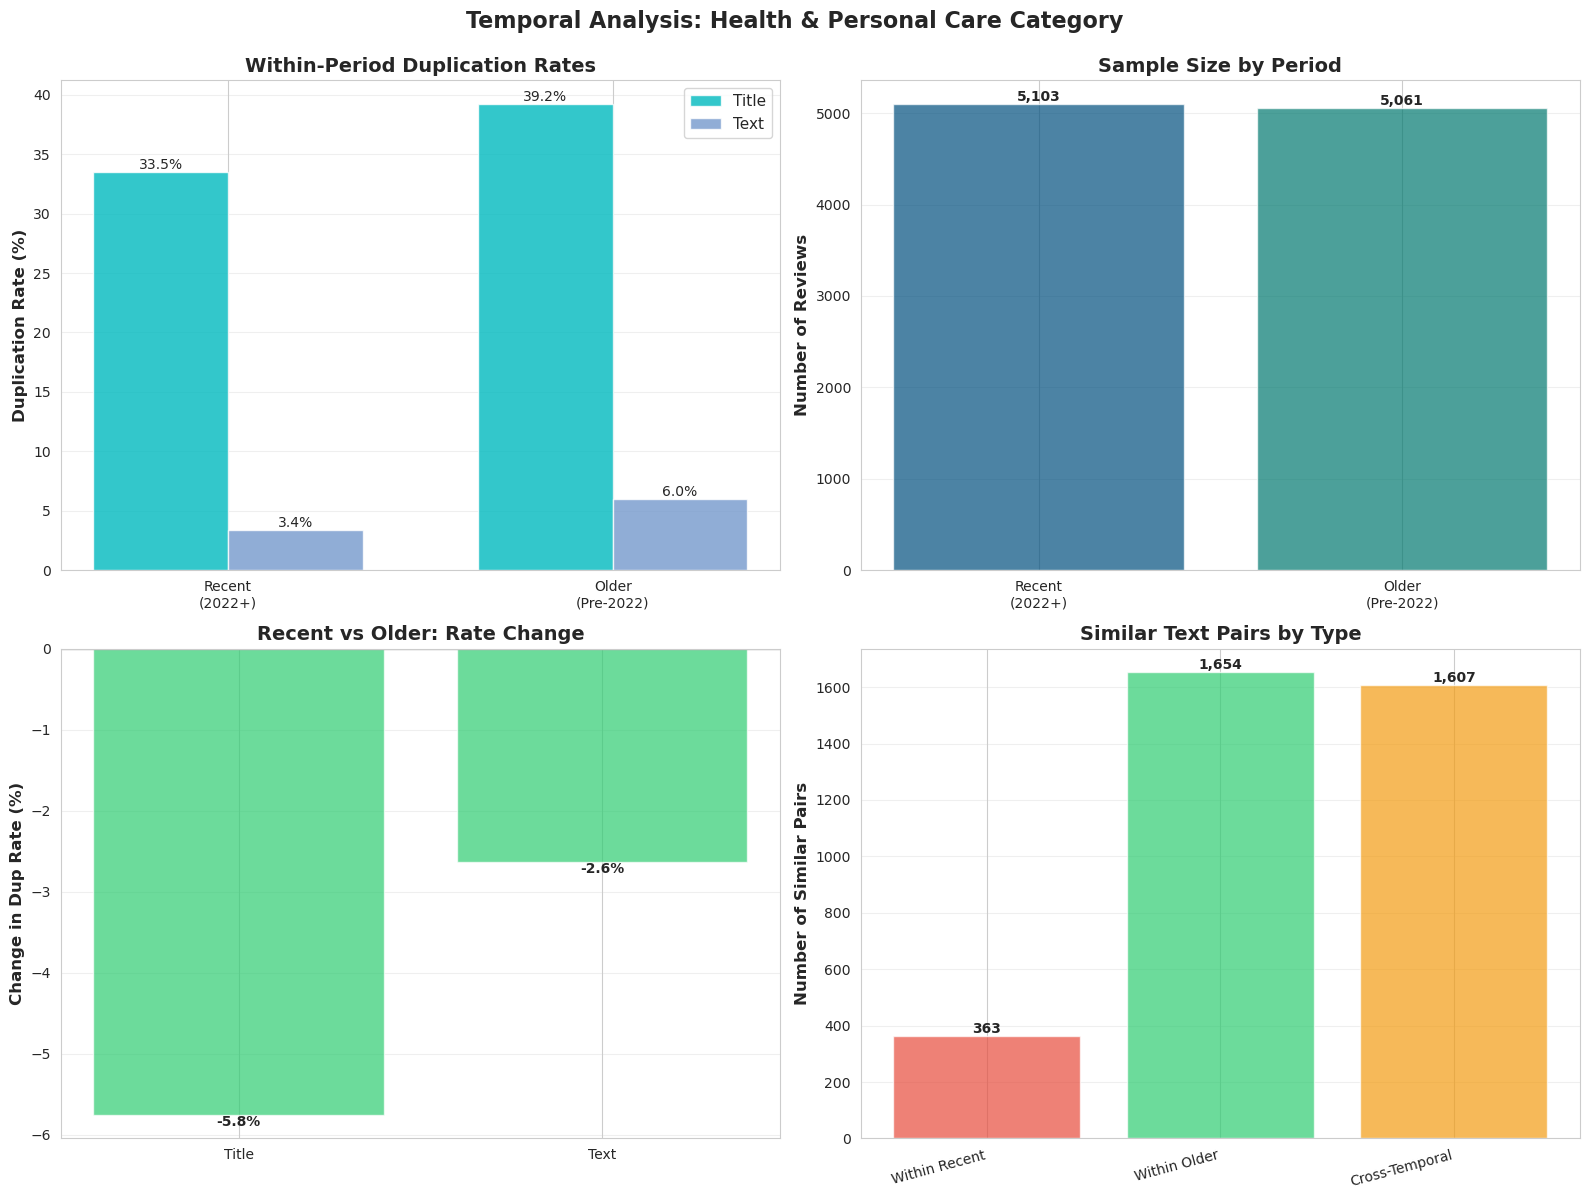


✓ Analysis complete!


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Within-period duplication comparison
periods = ['Recent\n(2022+)', 'Older\n(Pre-2022)']
title_rates = [recent_title_dup_rate, older_title_dup_rate]
text_rates = [recent_text_dup_rate, older_text_dup_rate]

x = np.arange(len(periods))
width = 0.35

bars1 = axes[0, 0].bar(x - width/2, title_rates, width, 
                       label='Title', color='#00babf', alpha=0.8)
bars2 = axes[0, 0].bar(x + width/2, text_rates, width, 
                       label='Text', color='#7599cc', alpha=0.8)

axes[0, 0].set_ylabel('Duplication Rate (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Within-Period Duplication Rates', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(periods)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# 2. Sample sizes
counts = [final_recent, final_older]
colors = ['#004f7e', '#00786f']
bars = axes[0, 1].bar(periods, counts, color=colors, alpha=0.7)
axes[0, 1].set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Sample Size by Period', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

for i, (bar, count) in enumerate(zip(bars, counts)):
    axes[0, 1].text(i, count, f'{count:,}', ha='center', va='bottom', 
                   fontsize=10, fontweight='bold')

# 3. Change analysis
if n_recent_total_texts > 0 and n_older_total_texts > 0:
    changes = [title_change, text_change]
    colors_change = ['#e74c3c' if c > 0 else '#2ecc71' for c in changes]
    
    bars = axes[1, 0].bar(['Title', 'Text'], changes, color=colors_change, alpha=0.7)
    axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    axes[1, 0].set_ylabel('Change in Dup Rate (%)', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Recent vs Older: Rate Change', fontsize=14, fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    for i, (bar, change) in enumerate(zip(bars, changes)):
        label = f'+{change:.1f}%' if change >= 0 else f'{change:.1f}%'
        va = 'bottom' if change >= 0 else 'top'
        axes[1, 0].text(i, change, label, ha='center', va=va, 
                       fontsize=10, fontweight='bold')

# 4. Cross-temporal duplication
if n_cross_temporal_pairs > 0:
    cross_data = ['Within Recent', 'Within Older', 'Cross-Temporal']
    cross_values = [n_recent_similar_text_pairs, n_older_similar_text_pairs, n_cross_temporal_pairs]
    colors_cross = ['#e74c3c', '#2ecc71', '#f39c12']
    
    bars = axes[1, 1].bar(cross_data, cross_values, color=colors_cross, alpha=0.7)
    axes[1, 1].set_ylabel('Number of Similar Pairs', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Similar Text Pairs by Type', fontsize=14, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    for i, (bar, val) in enumerate(zip(bars, cross_values)):
        axes[1, 1].text(i, val, f'{val:,}', ha='center', va='bottom', 
                       fontsize=10, fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'No cross-temporal\nduplicates found', 
                   ha='center', va='center', transform=axes[1, 1].transAxes,
                   fontsize=12, style='italic')
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])

plt.suptitle('Temporal Analysis: Health & Personal Care Category', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Analysis complete!")